# Jupyter Notebook to Visualize Data

In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np
import xgboost as xgb
from tqdm import tqdm

In [2]:
file_path = r'C:\Users\mafaq\Desktop\Orbevo-AI-v2\dataset\TrainData\XData.csv'
print(file_path)

C:\Users\mafaq\Desktop\Orbevo-AI-v2\dataset\TrainData\XData.csv


In [3]:
df = pd.read_csv(file_path)

In [4]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Coin_Name,Open_BTC,High_BTC,...,Price_STD,ATR,HistoricalVolatility,%K,%D,Tenkan_Sen,Kijun_Sen,Senkou_Span_A,Senkou_Span_B,Kumo
0,2021-03-19,51.433292,52.304642,48.108761,48.577850,48.577850,316367377,BTCST_Bitcoin-Standard-Hashrate-Token,57850.441406,59498.375000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,2021-03-20,48.467003,55.184586,45.101086,48.021317,48.021317,82789608,BTCST_Bitcoin-Standard-Hashrate-Token,58332.261719,60031.285156,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,2021-03-21,47.319103,47.848206,39.229626,39.229626,39.229626,48487576,BTCST_Bitcoin-Standard-Hashrate-Token,58309.914062,58767.898438,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
3,2021-03-22,39.223667,43.168190,36.315479,37.191551,37.191551,37841595,BTCST_Bitcoin-Standard-Hashrate-Token,57517.890625,58471.480469,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,2021-03-23,37.077858,39.090218,33.595436,34.062466,34.062466,20555111,BTCST_Bitcoin-Standard-Hashrate-Token,54511.660156,55985.441406,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67258,2023-05-21,0.016077,0.016799,0.015474,0.015945,0.015945,8878,CPH_Cypherium,27118.423828,27265.917969,...,0.001621,0.002597,1.303052,41.435201,39.179646,0.015976,0.019565,0.029925,0.064346,0
67259,2023-05-22,0.015944,0.016595,0.015649,0.016375,0.016375,7084,CPH_Cypherium,26749.892578,27045.734375,...,0.001620,0.002447,1.190727,50.484006,44.977098,0.015976,0.019484,0.028125,0.064346,0
67260,2023-05-23,0.016375,0.016382,0.015312,0.015812,0.015812,10399,CPH_Cypherium,26855.960938,27434.683594,...,0.001606,0.002199,1.160007,41.642093,44.520433,0.015976,0.019263,0.028125,0.064346,0
67261,2023-05-24,0.015812,0.016314,0.015452,0.015829,0.015829,11029,CPH_Cypherium,27224.603516,27224.603516,...,0.001319,0.002036,1.012877,46.325002,46.150367,0.015976,0.018474,0.028125,0.064346,0


In [5]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Coin_Name', 'Open_BTC', 'High_BTC', 'Low_BTC', 'Close_BTC',
       'Adj Close_BTC', 'Volume_BTC', 'Coin_Name_BTC', '24hChange',
       '24hChange_BTC', 'PriceRangeHigh', 'PriceRangeLow',
       'PriceRangeHigh_BTC', 'PriceRangeLow_BTC', 'Volume_Change',
       'BTC_Volume_Change', 'OBV', 'Volume_Oscillator', 'Average_Volume',
       'Relative_Volume', 'VSA_CB_Signal', 'VSA_CS_Signal',
       'Volume_Divergence', 'Money_Flow_Volume', 'A/D_Line', 'VMA5', 'VMA20',
       'VMA50', 'VMA100', 'VMA200', 'SMA_5', 'SMA_20', 'SMA_50', 'SMA_100',
       'SMA_200', 'EMA_5', 'EMA_20', 'EMA_50', 'EMA_100', 'EMA_200',
       'Bollinger_Middle_Band', 'Bollinger_Middle_Std_Dev',
       'Bollinger_Upper_Band', 'Bollinger_Lower_Band', 'RSI',
       'macd_signal_line', 'macd_histogram', 'Climax_Volume', 'Pivot',
       'Support1', 'Support2', 'Support3', 'Resistance1', 'Resistance2',
       'Resistance3', 'Price_STD', 'ATR', 'Hi

In [6]:
df.drop(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Coin_Name', 'Open_BTC', 'High_BTC', 'Low_BTC', 'Close_BTC',
       'Adj Close_BTC', 'Volume_BTC', 'Coin_Name_BTC'], axis=1, inplace=True)

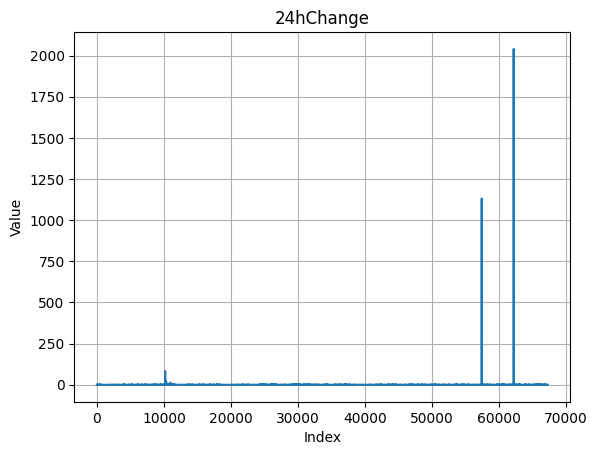

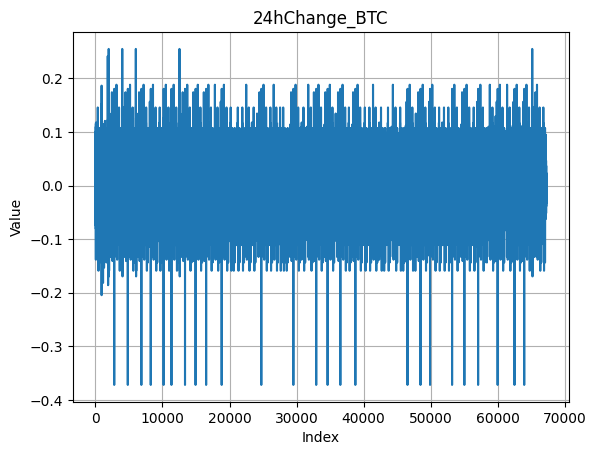

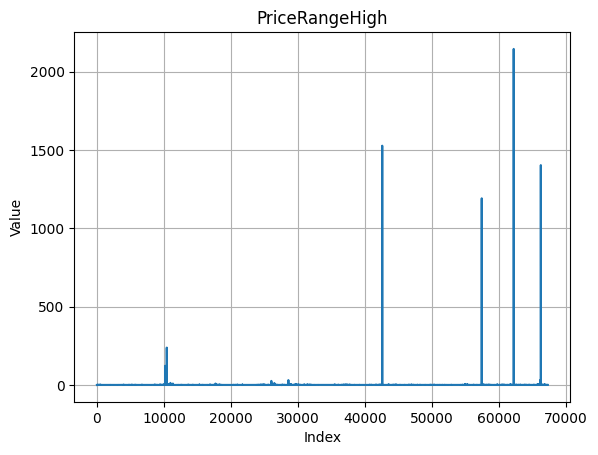

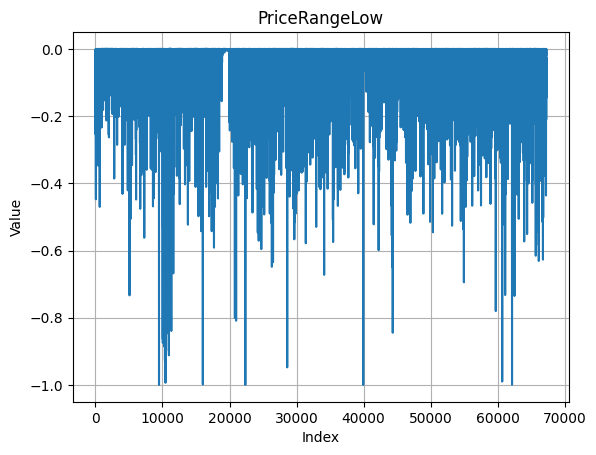

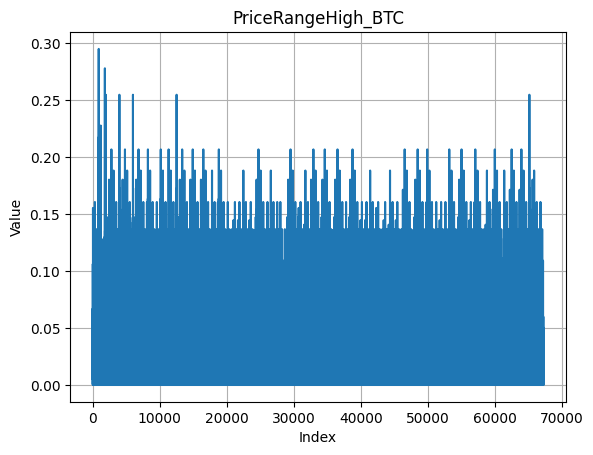

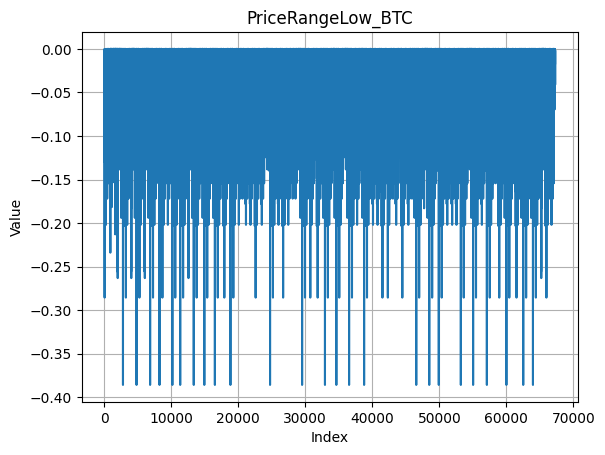

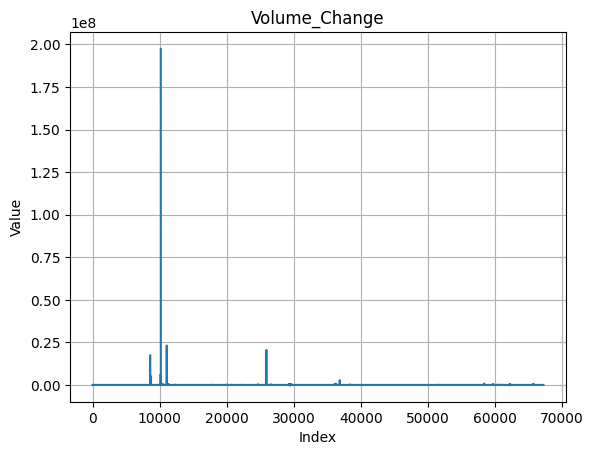

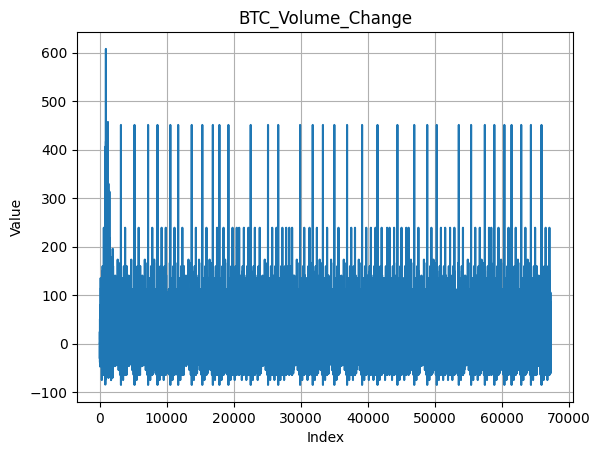

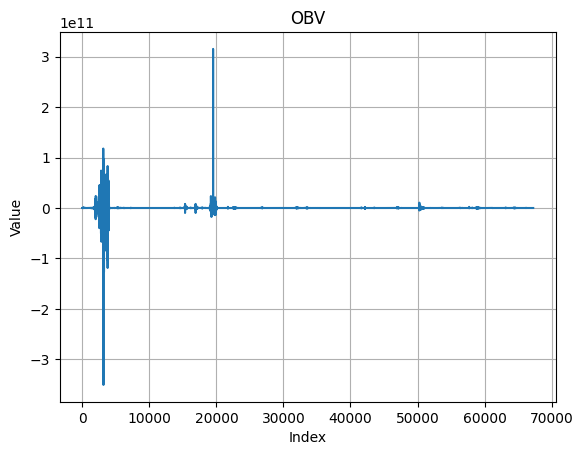

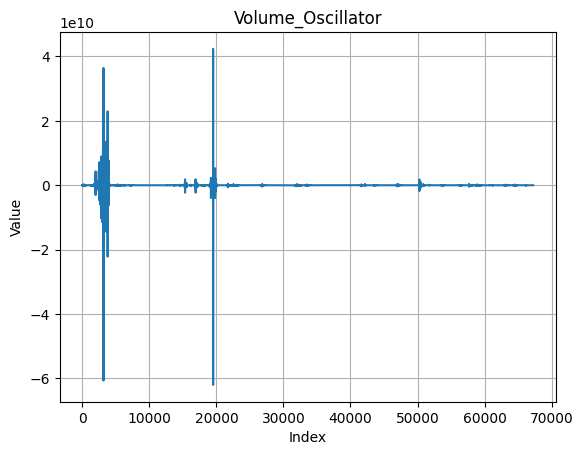

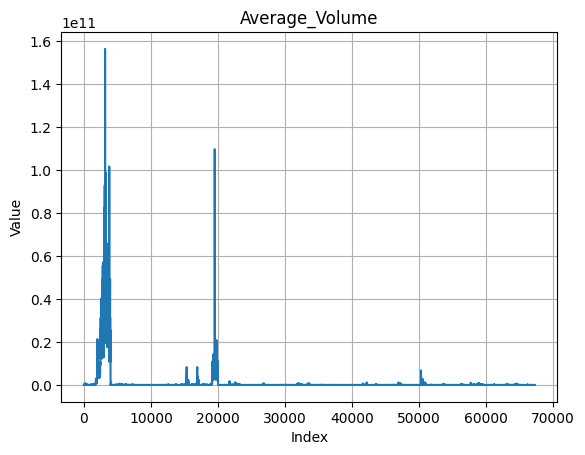

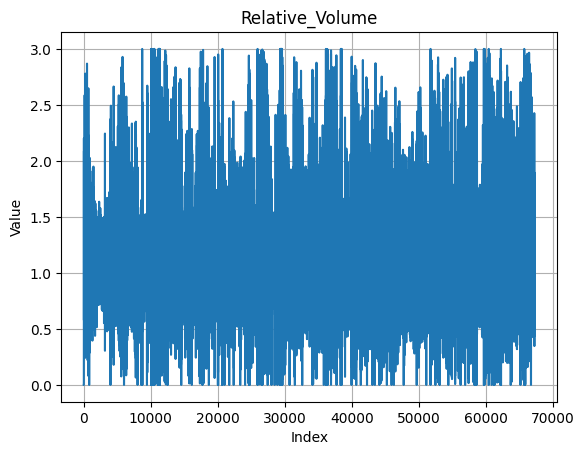

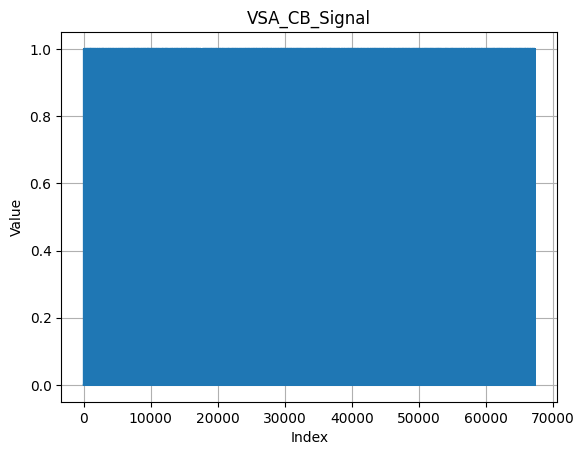

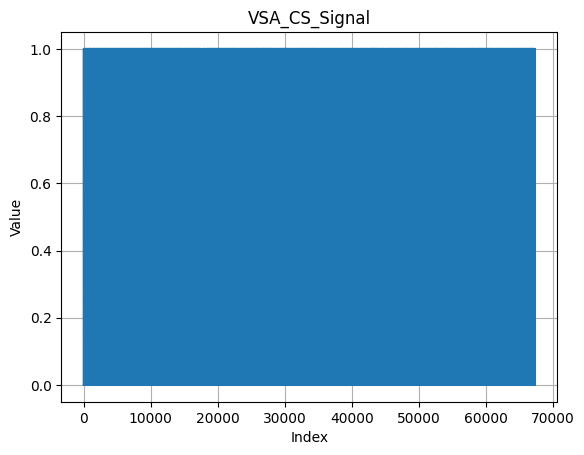

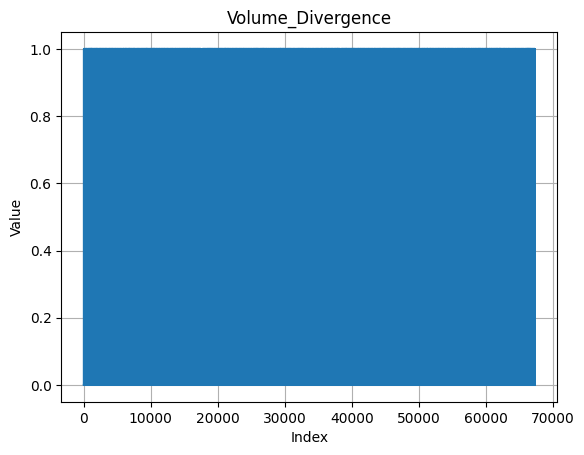

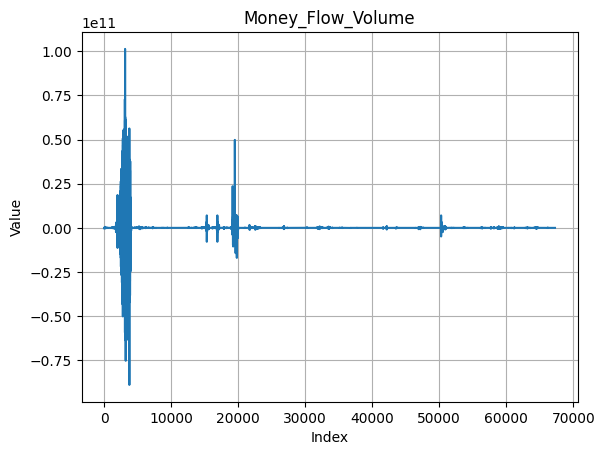

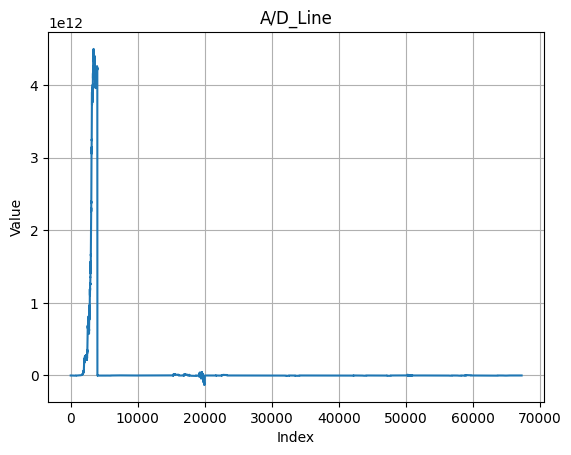

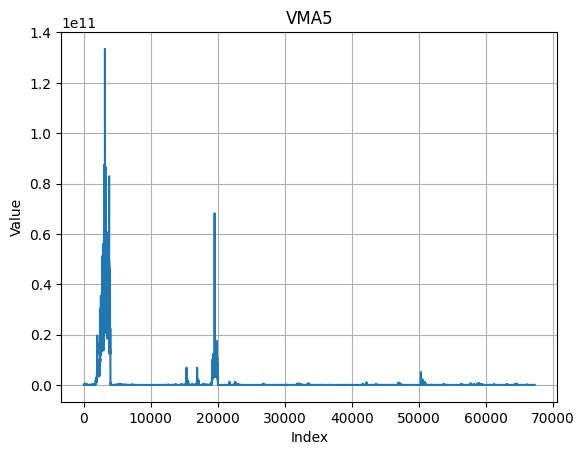

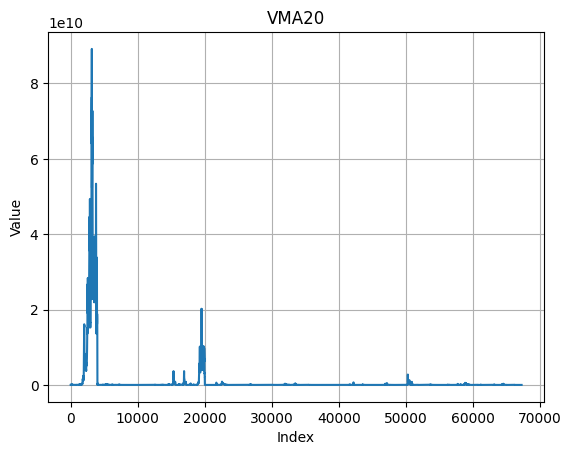

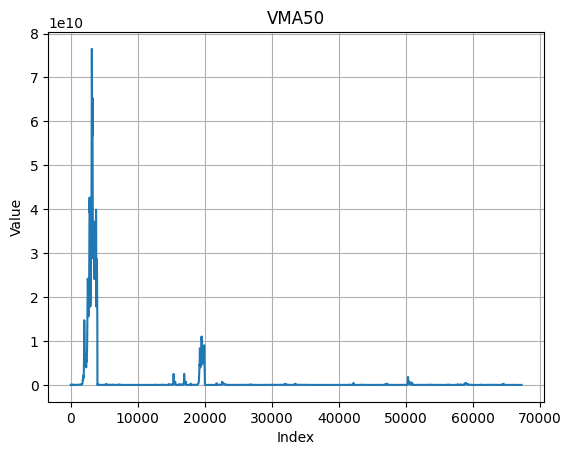

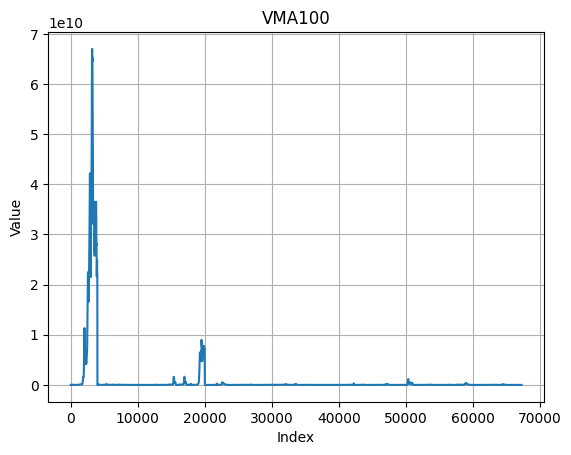

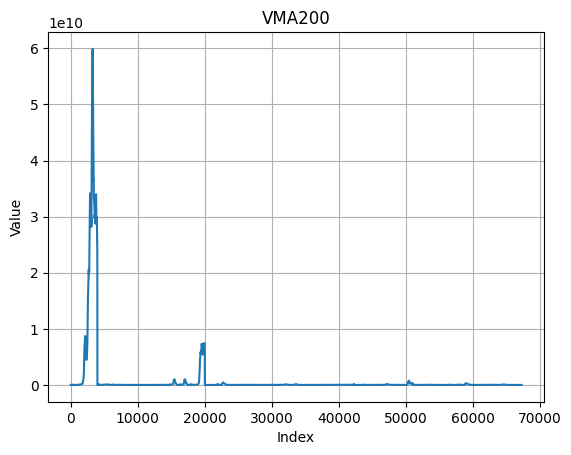

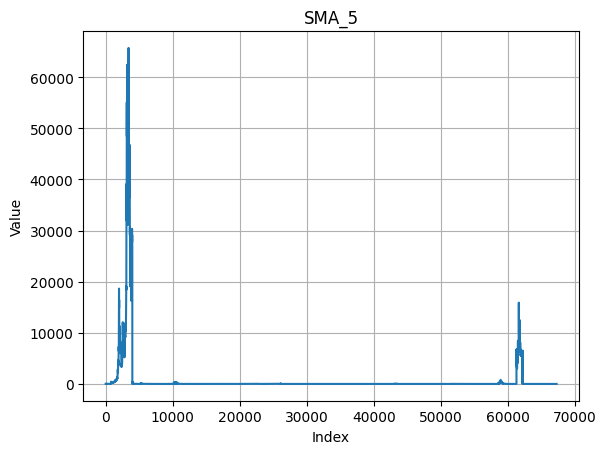

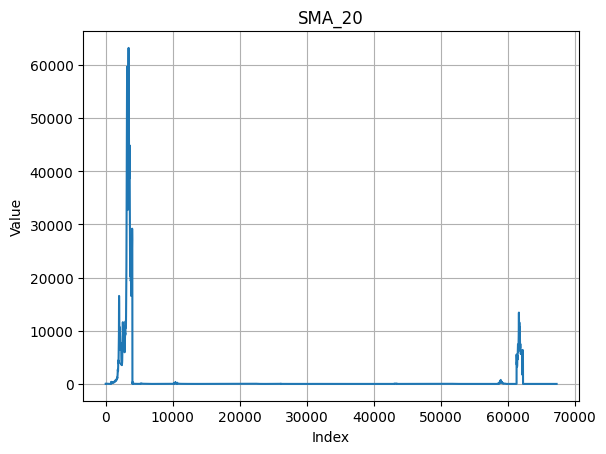

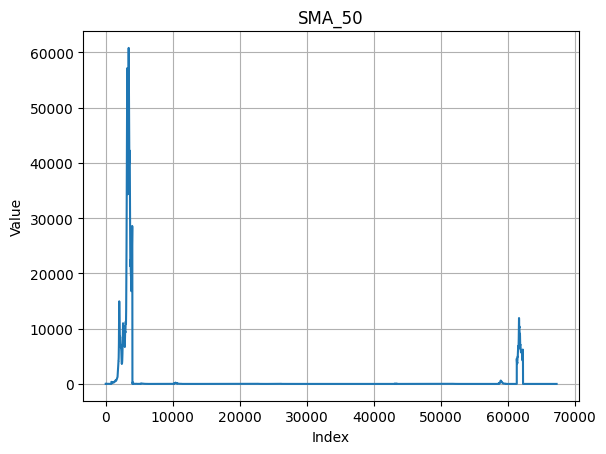

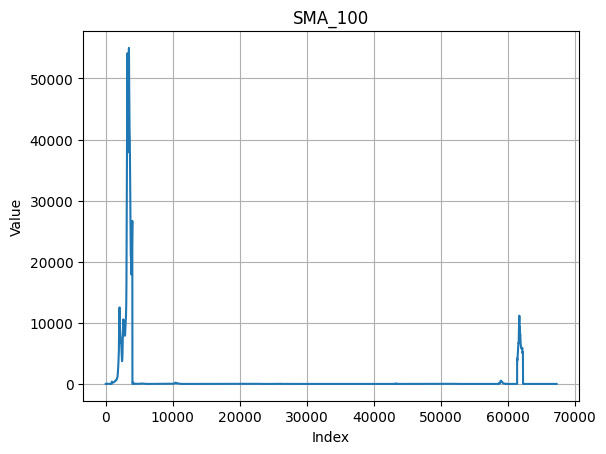

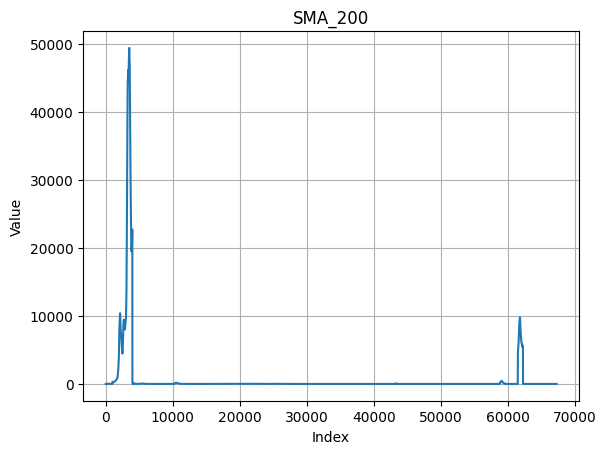

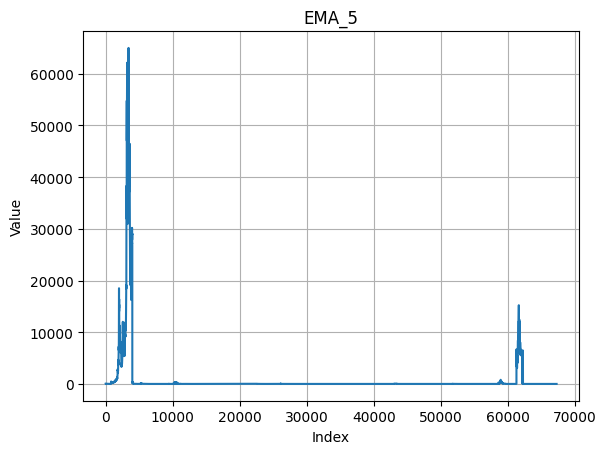

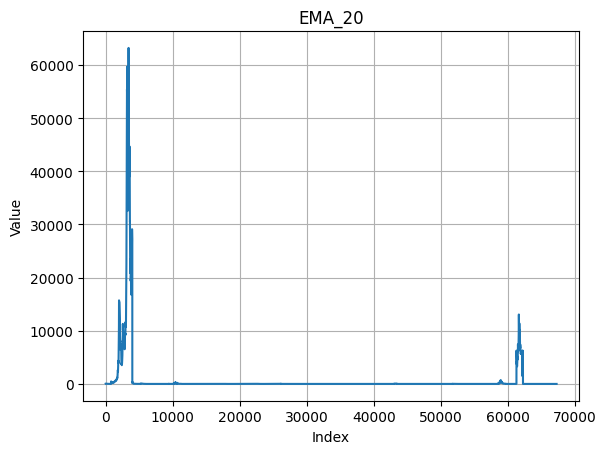

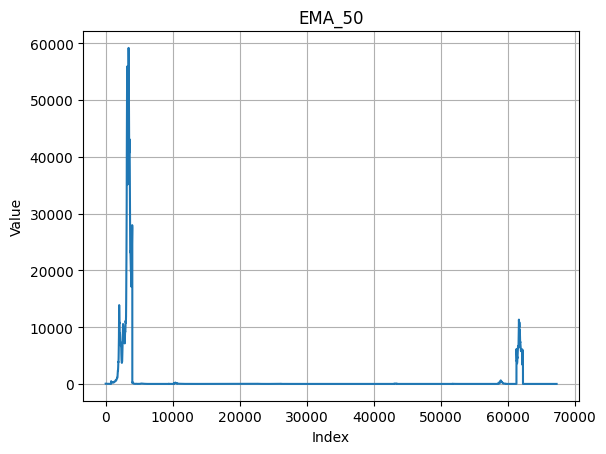

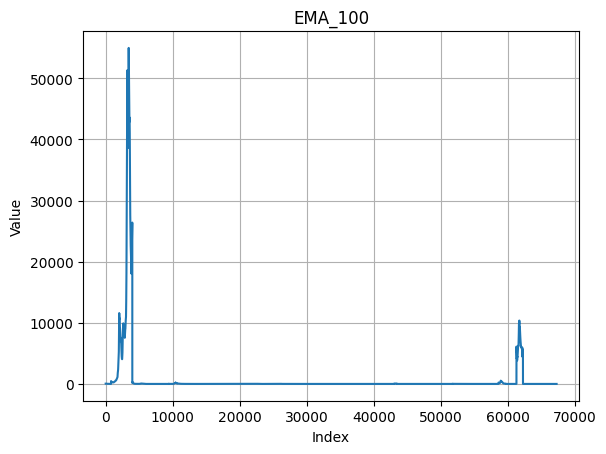

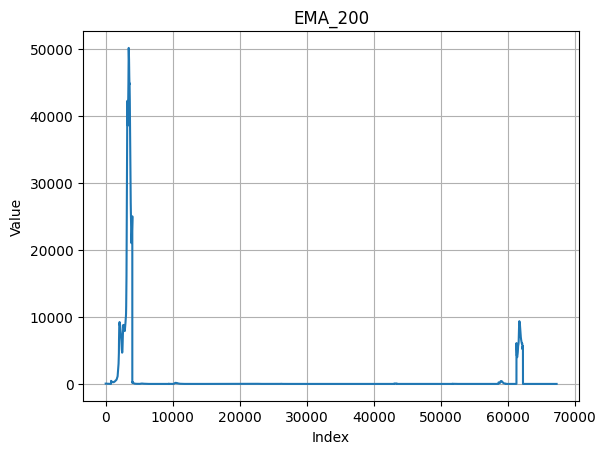

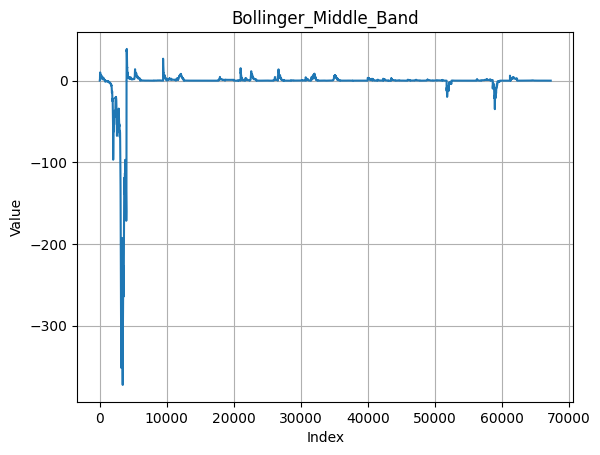

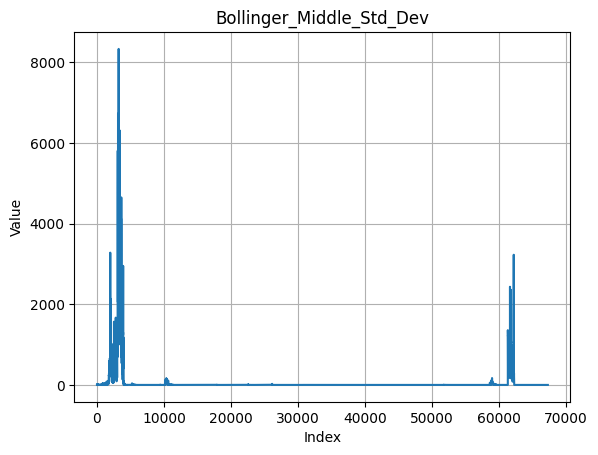

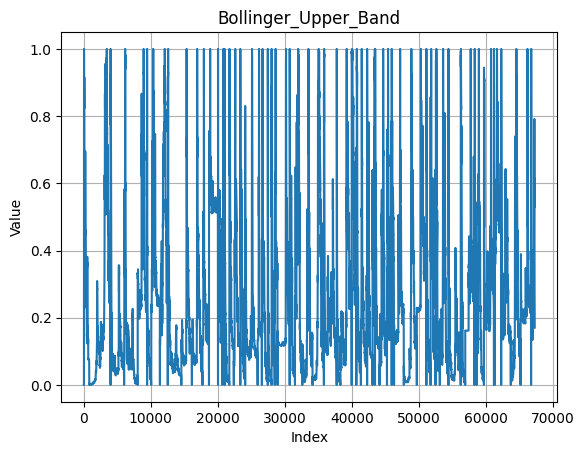

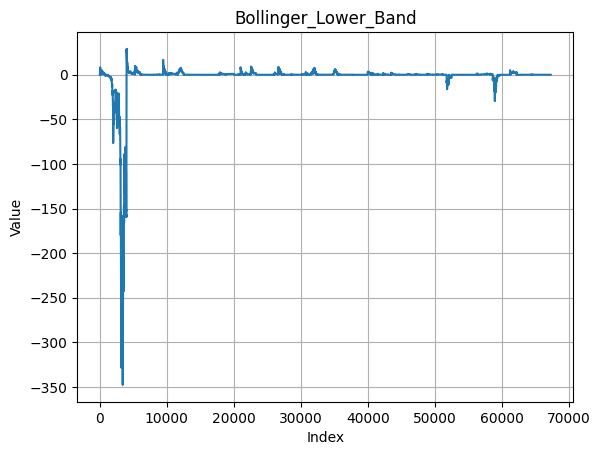

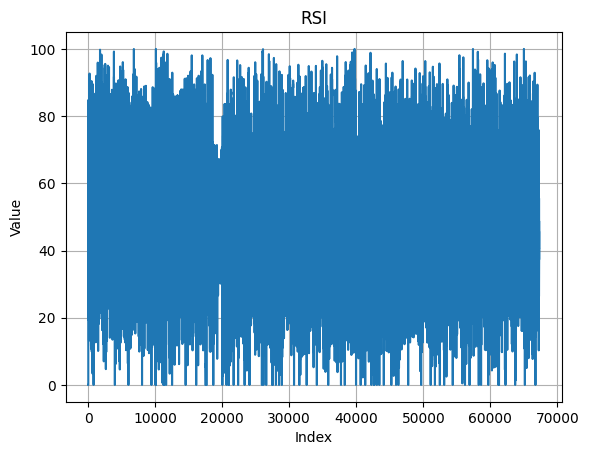

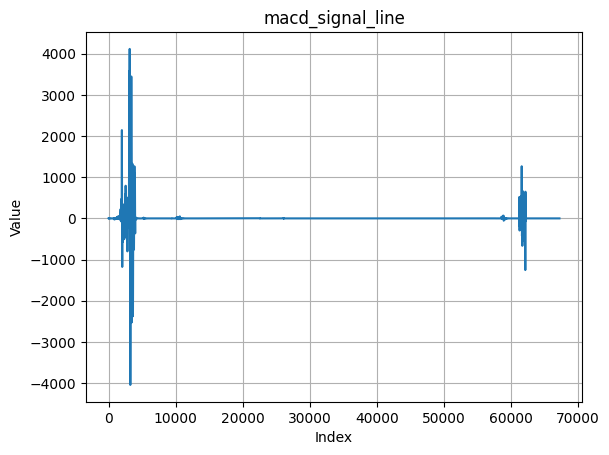

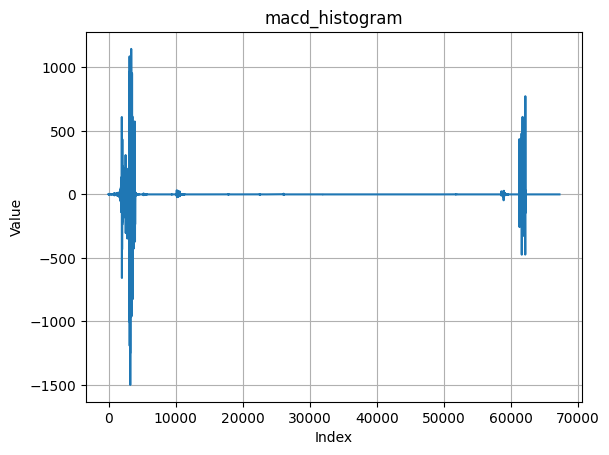

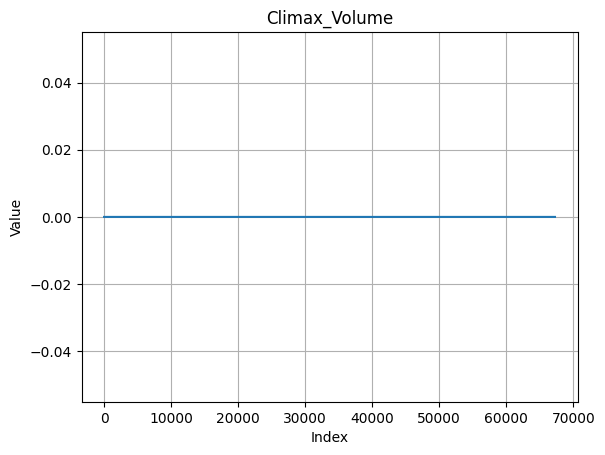

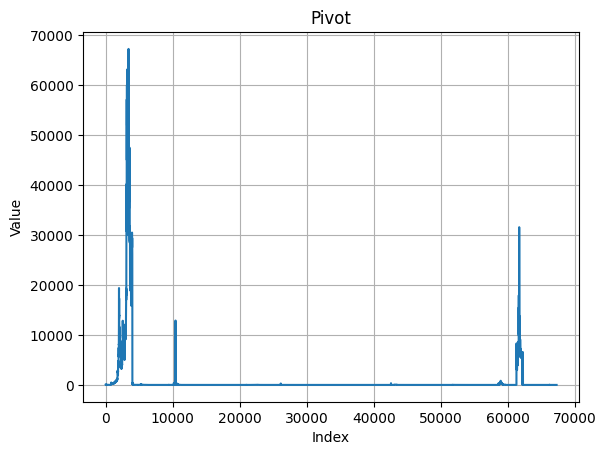

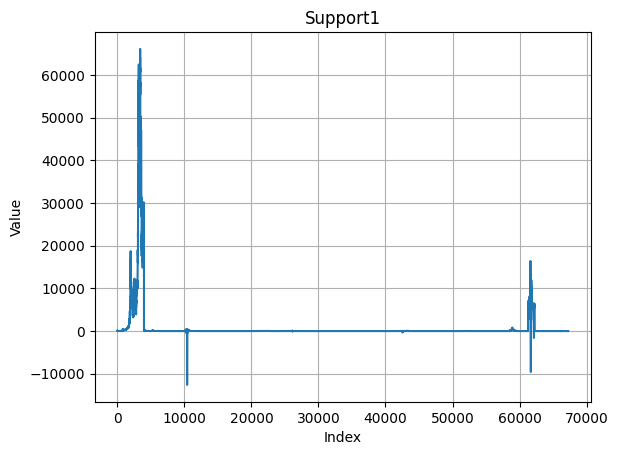

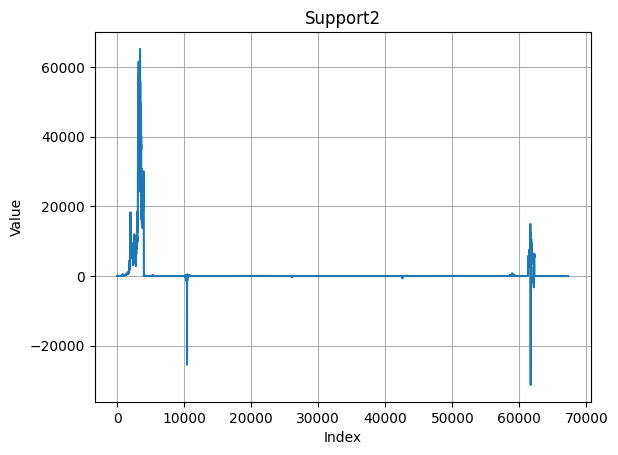

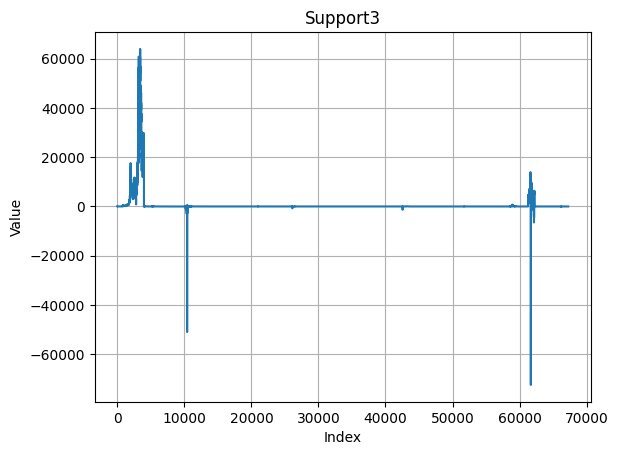

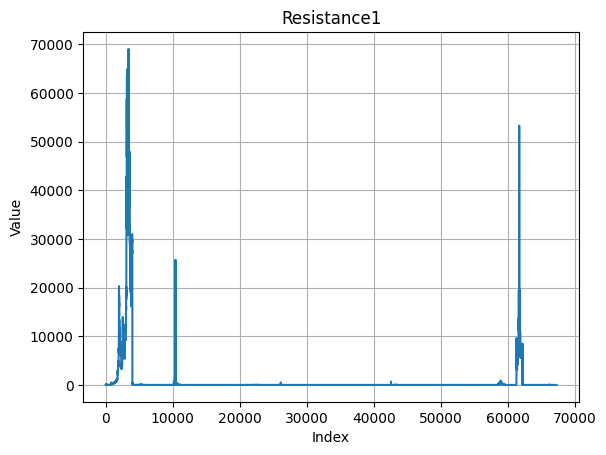

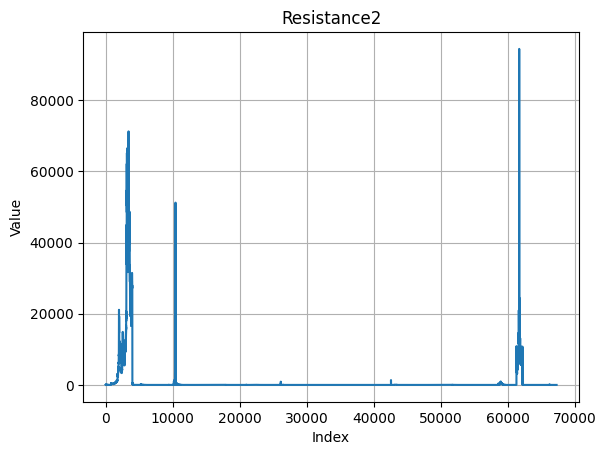

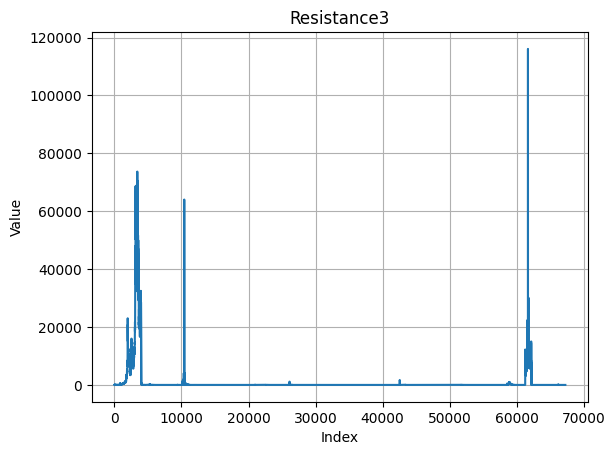

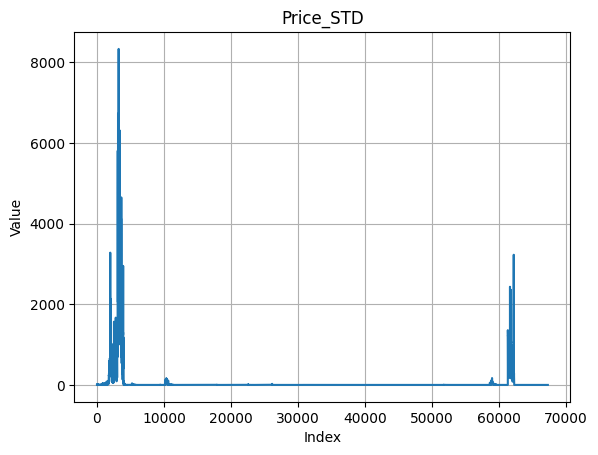

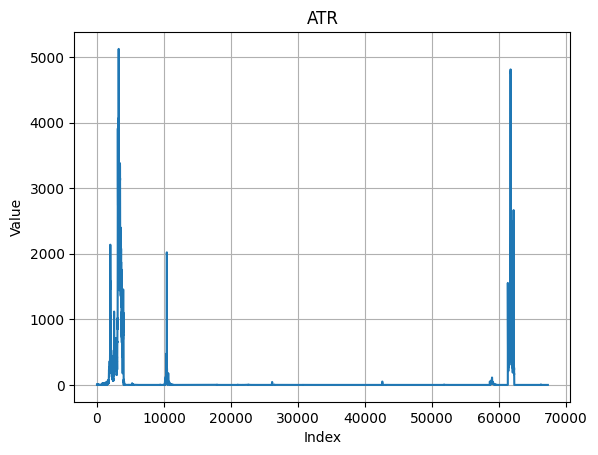

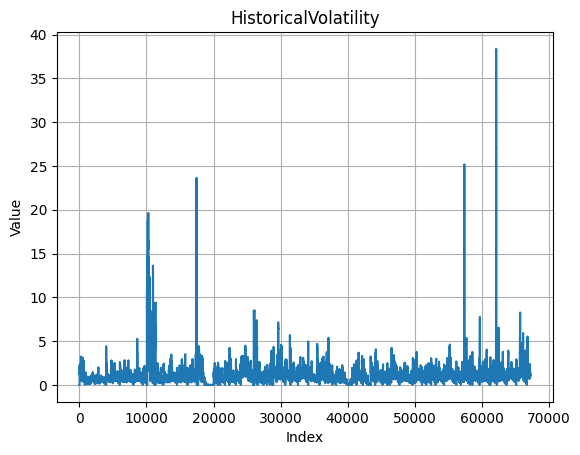

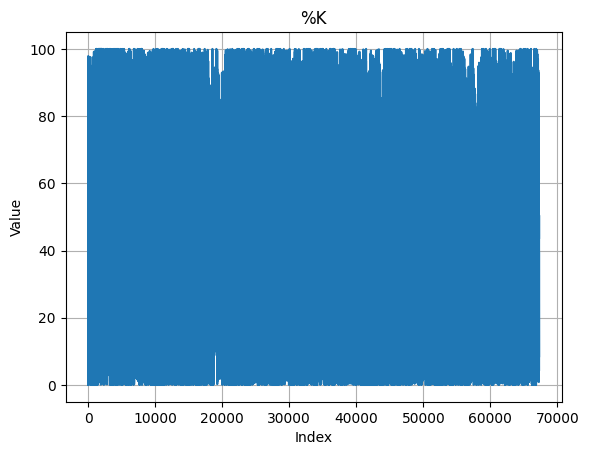

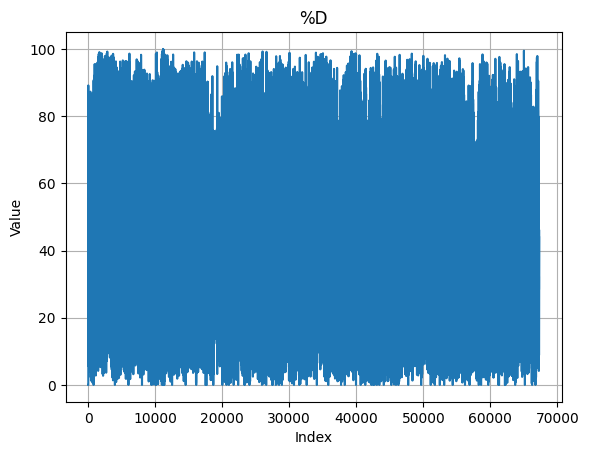

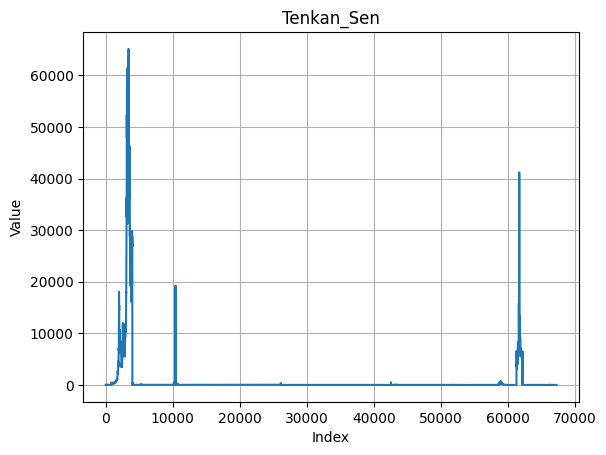

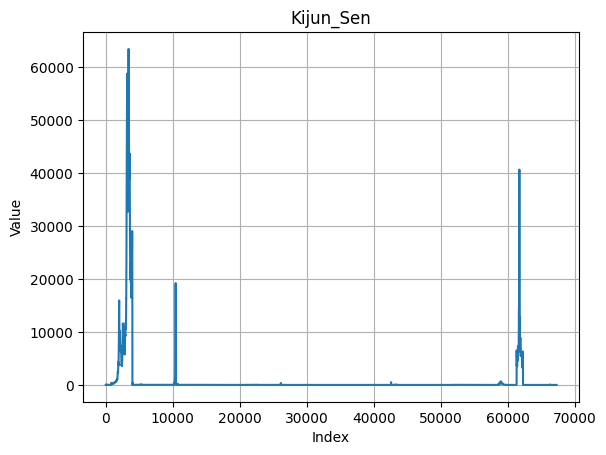

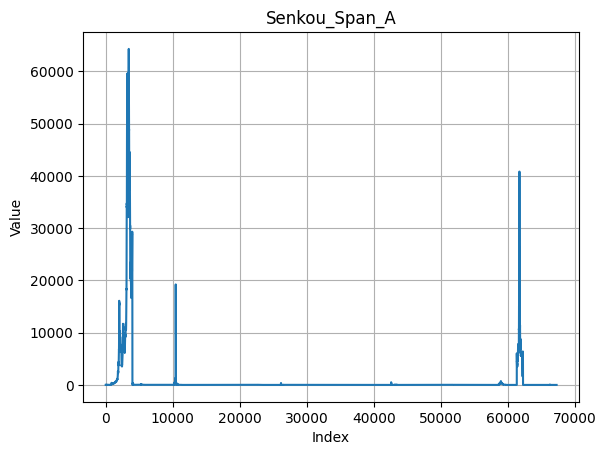

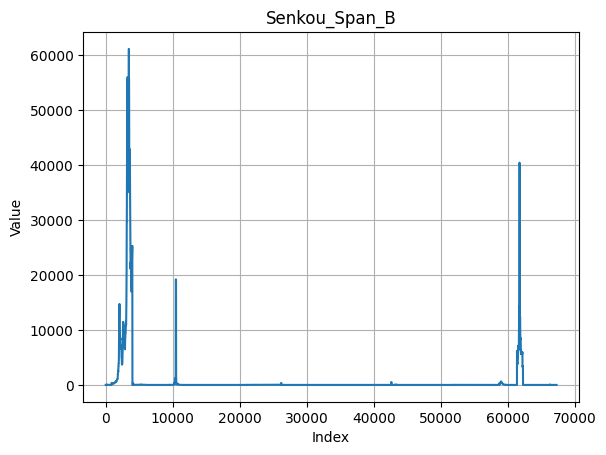

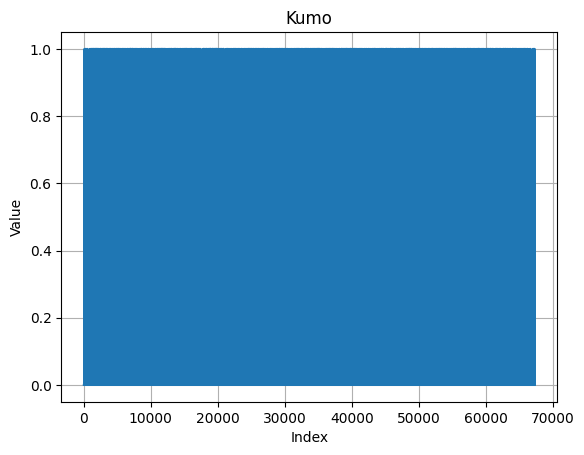

In [7]:
for column in df.columns:
    if(column!="Date"):
        plt.figure()  # Set the size of the figure
        plt.plot(df[column])         # Plot the data in the column
        plt.title(column)            # Set the title of the plot as the column name
        plt.xlabel('Index')          # Label for the x-axis
        plt.ylabel('Value')          # Label for the y-axis
        plt.grid(True)               # Add gridlines
        plt.show() 

In [8]:
Y_Data = df.copy()  # Create a copy of the original DataFrame

# Use the shift function to compare Close with the next row's Open
Y_Data['Prediction'] = (Y_Data['24hChange'].shift(-1) > 0).astype(int)
Y_Data = Y_Data[['Prediction']]

In [9]:
Y_Data

,Prediction
0,0
1,0
2,0
3,0
4,0
...,...
67258,1
67259,0
67260,1
67261,0


In [10]:
X_Data=df.sample(frac=1).reset_index(drop=True)
X_Data.replace([np.inf, -np.inf], 0, inplace=True)

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X_Data, Y_Data, test_size=0.2, random_state=42)


In [12]:
print("shape of X_train = " + str(np.shape(X_train)))
print("shape of X_test = " + str(np.shape(X_test)))
print("shape of Y_train = " + str(np.shape(Y_train)))
print("shape of Y_test = " + str(np.shape(Y_test)))

shape of X_train = (53810, 57)
shape of X_test = (13453, 57)
shape of Y_train = (53810, 1)
shape of Y_test = (13453, 1)


In [13]:
X_Data.columns

Index(['24hChange', '24hChange_BTC', 'PriceRangeHigh', 'PriceRangeLow',
       'PriceRangeHigh_BTC', 'PriceRangeLow_BTC', 'Volume_Change',
       'BTC_Volume_Change', 'OBV', 'Volume_Oscillator', 'Average_Volume',
       'Relative_Volume', 'VSA_CB_Signal', 'VSA_CS_Signal',
       'Volume_Divergence', 'Money_Flow_Volume', 'A/D_Line', 'VMA5', 'VMA20',
       'VMA50', 'VMA100', 'VMA200', 'SMA_5', 'SMA_20', 'SMA_50', 'SMA_100',
       'SMA_200', 'EMA_5', 'EMA_20', 'EMA_50', 'EMA_100', 'EMA_200',
       'Bollinger_Middle_Band', 'Bollinger_Middle_Std_Dev',
       'Bollinger_Upper_Band', 'Bollinger_Lower_Band', 'RSI',
       'macd_signal_line', 'macd_histogram', 'Climax_Volume', 'Pivot',
       'Support1', 'Support2', 'Support3', 'Resistance1', 'Resistance2',
       'Resistance3', 'Price_STD', 'ATR', 'HistoricalVolatility', '%K', '%D',
       'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Kumo'],
      dtype='object')

## Classifier


In [14]:
xgb_classifier = xgb.XGBClassifier()

In [27]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1],
    'n_estimators': [100, 200, 300],
    'reg_alpha': [0.01, 0.1, 1.0],
    'reg_lambda': [0.01, 0.1, 1.0]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid, cv=5)
grid_search.fit(X_train, Y_train)

# Get the best hyperparameter configuration
best_params = grid_search.best_params_

# Train the XGBoost classifier with the best hyperparameters
best_xgb_classifier = xgb.XGBClassifier(**best_params)
best_xgb_classifier.fit(X_train, Y_train)

# Make predictions on the testing set
Y_pred = best_xgb_classifier.predict(X_test)

In [28]:
print("Best Params are")
print(best_params)

Best Params are
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1.0}


In [29]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.524492678213038
